In [166]:
!pip install python-dotenv


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from dotenv import load_dotenv  # подключаем .env файл с секретами
import requests  # делаем HTTP-запросы
import os  # читаем переменные окружения
import json

load_dotenv()  # загружаем переменные из .env
CLIENT_ID = 54386297  # получаем CLIENT_ID из .env

# формируем ссылку для получения access_token через OAuth
url = f"https://oauth.vk.com/authorize?client_id={CLIENT_ID}&redirect_uri=https://oauth.vk.com/blank.html&response_type=token&scope=8194"

response = requests.get(url, allow_redirects=True)  # отправляем запрос и следуем редиректам
print(response.url)  # выводим финальный URL, где в адресной строке будет access_token

https://oauth.vk.com/authorize?client_id=54386257&redirect_uri=https://oauth.vk.com/blank.html&response_type=token&scope=8194


In [232]:
access_token = "vk1.a.zR1HMpZIpbIED5aYcocNKCRvnylOkfXpvZqpufuevhO07uGipLpp8PbmNUdB0O3QXXv5Ncg_KHpAOUoTCDy2ceFUqks-Z37eKcKVVOZY_r_aaA1VCsbAjTx7HL4S_Yj_w_Z9-LOLGOSljGb2P9Kq6nLXdCOG4W3ohh_XYda6vDjHu2Q6sXe5K7mud75Q-S04qXA5OGUl_mxwrSC0K2wIzA"

In [233]:
# Константы (лучше вынести в конфиг или .env)
VK_API_BASE = "https://api.vk.ru/method/"
API_VERSION = "5.131"


def make_vk_request(method, params=None):
    """
    Отправляет GET-запрос к API ВКонтакте.

    :param method: Название метода API (например, 'users.get')
    :param params: Словарь с параметрами запроса (без v и access_token — они добавятся автоматически)
    :return: Ответ API в формате JSON или None при ошибке
    """
    url = f"{VK_API_BASE}{method}"
    # Создаём копию параметров, чтобы не изменять исходный словарь
    request_params = (params or {}).copy()
    # Автоматически добавляем обязательные параметры
    request_params["v"] = API_VERSION
    request_params["access_token"] = access_token

    response = requests.get(url, params=request_params)

    if response.status_code == 200:
        return response.json()
    else:
        print("Ошибка при выполнении запроса:", response.status_code, response.text)
        return None

In [234]:
params = {
    "user_ids": "a.kryukov0",
    "name_case": "nom"
}

data = make_vk_request("users.get", params)

if data:
    print("Ответ:", data)
    if "response" in data:
        result_array = data["response"]
        central_user_id = result_array[0]['id']
        print(f"id пользователя для запроса списка друзей {central_user_id}")
    else:
        print("Ключ 'response' отсутствует в ответе:", data)

Ответ: {'response': [{'id': 253997298, 'first_name': 'Александр', 'last_name': 'Крюков', 'can_access_closed': True, 'is_closed': False}]}
id пользователя для запроса списка друзей 253997298


In [249]:
# Ограничения (API VK имеет лимиты)
MAX_DEPTH = 2
MAX_FRIENDS_PER_USER = 50  # Ограничим для скорости и лимитов
REQUEST_DELAY = 0.35  # Задержка между запросами (в сек), чтобы не превысить лимиты

def get_friends(user_id, fields=None):
    """
    Возвращает список друзей одного пользователя (один уровень).
    Параллельно сохраняет полный ответ friends.get в friends_<id>.json.
    Добавлена обработка ошибок через try/except.
    """
    try:
        params = {
            "user_id": user_id,
            "count": MAX_FRIENDS_PER_USER
        }
        if fields:
            params["fields"] = fields

        response = make_vk_request("friends.get", params)

        # Нет ответа или ошибка
        if not response:
            print(f"[Ошибка] Нет ответа от VK для user_id={user_id}")
            return []

        if "error" in response:
            print(f"[VK ERROR] user_id={user_id}: {response['error']}")
            return []

        if "response" not in response:
            print(f"[Ошибка] Нет ключа 'response' в ответе VK для user_id={user_id}")
            return []

        payload = response["response"]

        # Пишем полный JSON-файл
        filename = f"friends_{user_id}.json"
        try:
            with open(filename, "w", encoding="utf-8") as file:
                json.dump(payload, file, ensure_ascii=False, indent=4)
            print(f"Файл сохранён: {filename}")
        except Exception as file_err:
            print(f"[Ошибка записи файла] {filename}: {file_err}")

        # Возвращаем список друзей (в виде объектов, если fields были)
        return payload.get("items", [])

    except Exception as e:
        print(f"[Исключение] get_friends({user_id}) завершился с ошибкой: {e}")
        return []


In [ ]:
# Тестируем получение друзей
get_friends(central_user_id, fields=["city", "sex", "bdate", "first_name", "last_name"])

Файл сохранён: friends_253997298.json


[{'id': 109210,
  'track_code': 'f6efac81G_94i-HrcsDX9xzFuK73diPuMSJ2EhZ5tDtATeHepBV2lHe73uNwzIeiLFxfWxUZVPpDSxN8',
  'first_name': 'Инга',
  'last_name': 'Нарбекова',
  'can_access_closed': True,
  'is_closed': False},
 {'id': 5501334,
  'track_code': 'b67a2e9dmaaQjGgb7mg-ViWoysIBVOElkR1bRBkGDB6WKXnJzF_0zcnqDR7ib21WFwNGO_AimCaRdD4qfQ',
  'first_name': 'Татьяна',
  'last_name': 'Белоусова',
  'can_access_closed': True,
  'is_closed': False},
 {'id': 6025948,
  'track_code': 'b564da4ckJXivxmOgk8Of3L7ZzdZMmXQZmmpJfy0_25tb_oiaJ79_ujZLNyBTg0jRFzrzqhEHNNmAMxLmA',
  'first_name': 'Мария',
  'last_name': 'Савинкина',
  'can_access_closed': True,
  'is_closed': False},
 {'id': 6098838,
  'track_code': '61c5ff65t_U3VmTCGIPeEeudxFzzHzcdBzbbebg9MrxSFq5bOMXanmxhAsRLi4JP2zpIpQJpTh4HX74X3A',
  'deactivated': 'deleted',
  'first_name': 'Валентин',
  'last_name': 'Киблык',
  'can_access_closed': True,
  'is_closed': False},
 {'id': 7112155,
  'track_code': '345987aaCq_REEDA5vxiktosJlnan6X1mc8Msf3v76nQ

In [242]:
import json
import csv
from collections import deque
from time import sleep

import csv

def build_friends_graph(root_id, fields=None, max_depth=MAX_DEPTH):
    visited = set()
    queue = deque([(root_id, 0)])

    graph_rows = []   # СЮДА будем собирать строки для одного CSV

    # будем кешировать инфу о пользователях, чтобы не дёргать VK лишний раз
    users_cache = {}

    while queue:
        uid, depth = queue.popleft()
        if depth >= max_depth or uid in visited:
            continue
        visited.add(uid)

        # получаем друзей с полями
        friends = get_friends(uid, fields=fields)

        # инфа о самом пользователе (from_*)
        if uid not in users_cache:
            # ищем uid среди friends (для root это не сработает, можно оставить пустым)
            users_cache[uid] = {}

        from_info = users_cache.get(uid, {})
        from_sex = from_info.get("sex")
        from_city = from_info.get("city", {}).get("title") if isinstance(from_info.get("city"), dict) else None
        from_first = from_info.get("first_name")
        from_last = from_info.get("last_name")

        for friend in friends:
            fid = friend["id"]

            # кладём инфу о друге в кеш
            users_cache[fid] = friend

            to_sex = friend.get("sex")
            to_city = friend.get("city", {}).get("title") if isinstance(friend.get("city"), dict) else None
            to_first = friend.get("first_name")
            to_last = friend.get("last_name")

            graph_rows.append({
                "from_id": uid,
                "to_id": fid,
                "from_sex": from_sex,
                "to_sex": to_sex,
                "from_city": from_city,
                "to_city": to_city,
                "from_first_name": from_first,
                "from_last_name": from_last,
                "to_first_name": to_first,
                "to_last_name": to_last,
            })

            if depth + 1 < max_depth:
                queue.append((fid, depth + 1))

        sleep(REQUEST_DELAY)

    # сохраняем ОДИН CSV
    csv_name = f"friends_graph_{root_id}.csv"
    fieldnames = [
        "from_id", "to_id",
        "from_sex", "to_sex",
        "from_city", "to_city",
        "from_first_name", "from_last_name",
        "to_first_name", "to_last_name",
    ]
    with open(csv_name, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(graph_rows)

    print(f"Граф сохранён в CSV: {csv_name}")
    return graph_rows


In [245]:
fields=["city", "sex", "bdate", "first_name", "last_name"]

graph_rows = build_friends_graph(
    root_id=central_user_id,
    fields=fields,
    max_depth=MAX_DEPTH
)


Файл сохранён: friends_253997298.json
Файл сохранён: friends_109210.json
Файл сохранён: friends_5501334.json
Файл сохранён: friends_6025948.json
[VK ERROR] user_id=6098838: {'error_code': 18, 'error_msg': 'User was deleted or banned', 'request_params': [{'key': 'user_id', 'value': '6098838'}, {'key': 'count', 'value': '10'}, {'key': 'fields', 'value': 'last_name'}, {'key': 'v', 'value': '5.131'}, {'key': 'method', 'value': 'friends.get'}, {'key': 'oauth', 'value': '1'}]}
Файл сохранён: friends_7112155.json
Файл сохранён: friends_7492381.json
Файл сохранён: friends_10379486.json
Файл сохранён: friends_12533719.json
Файл сохранён: friends_16562531.json
Файл сохранён: friends_17107945.json
Граф сохранён в CSV: friends_graph_253997298.csv


In [191]:
!pip install networkx matplotlib


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Найдено кластеров: 1


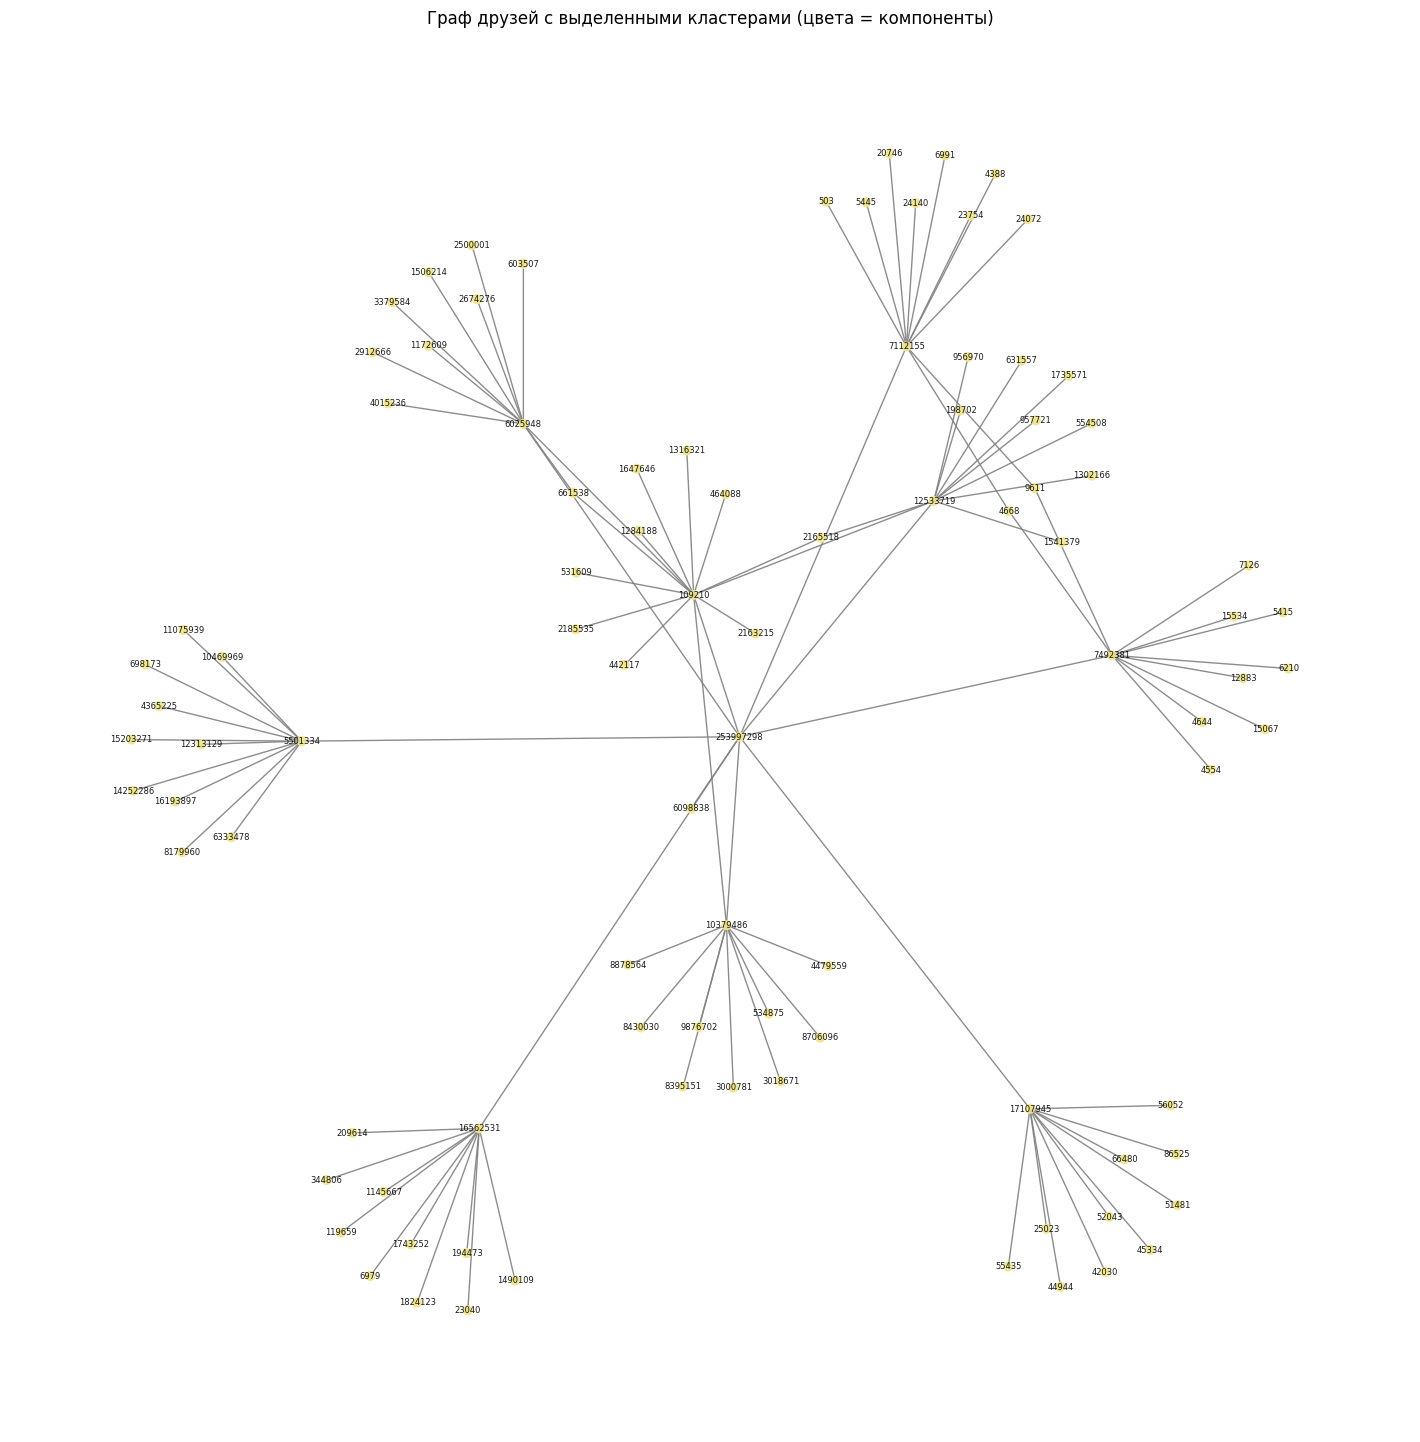

In [246]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
import random

# читаем CSV с рёбрами
df_edges = pd.read_csv(f"friends_graph_{central_user_id}.csv")

# строим граф
G = nx.from_pandas_edgelist(df_edges, "from_id", "to_id")

# находим кластеры (компоненты связи)
components = list(nx.connected_components(G))

print(f"Найдено кластеров: {len(components)}")

# генерируем столько цветов, сколько кластеров
color_list = list(mcolors.CSS4_COLORS.values())
random.shuffle(color_list)

cluster_colors = {}
for i, comp in enumerate(components):
    color = color_list[i % len(color_list)]  # если цветов меньше — повторяем
    for node in comp:
        cluster_colors[node] = color

# цвета узлов в порядке обхода графа
node_colors = [cluster_colors[node] for node in G.nodes()]

# рисуем
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_color=node_colors,
    with_labels=True,      # показать ID на графе
    font_size=6,
    node_size=40,
    edge_color="gray",
    alpha=0.9,
)

plt.title("Граф друзей с выделенными кластерами (цвета = компоненты)")
plt.show()
